# Imports and (optional) mock data generation 

In [30]:
# Cell 1: Imports & mock data generator
import pandas as pd
import numpy as np
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Callable
import matplotlib.pyplot as plt
import uuid
from datetime import datetime, timedelta

plt.rcParams["figure.figsize"] = (10,4)


# Optional: generate mock price path + client trades if you don't have CSVs
def make_price_path(start="2025-09-24 08:00", end="2025-09-24 18:00",
                    freq="1min", start_mid=1.10, seed=42, vol_bps_per_min=0.8):
    rng = np.random.default_rng(seed)
    times = pd.date_range(start, end, freq=freq, tz="Europe/London")
    n = len(times)
    sigma = vol_bps_per_min / 1e4
    shocks = rng.normal(0, sigma, size=n)
    mid = np.empty(n)
    mid[0] = start_mid
    for i in range(1, n):
        mid[i] = mid[i-1] * (1 + shocks[i])
    return pd.DataFrame({"ts": times, "mid": mid})

def make_trades_from_price(price_df, trade_prob=0.35, size_mean=12.4, size_sigma=0.5, seed=7, n_clients=30):
    rng = np.random.default_rng(seed)
    trades = []
    for row in price_df.itertuples(index=False):
        if rng.random() < trade_prob:
            # sign FROM OUR perspective: +1 we buy ccy1, -1 we sell ccy1
            side = 1 if rng.random() < 0.5 else -1
            qty = float(rng.lognormal(mean=size_mean, sigma=size_sigma))
            px = row.mid
            client_id = f"C{rng.integers(1, n_clients+1)}"
            trades.append({"ts": row.ts, "side": side, "qty": qty, "px": px, "mid": row.mid, "client_id": client_id})
    return pd.DataFrame(trades)

# Generate mock if needed
price_df = make_price_path()
trade_df = make_trades_from_price(price_df)
price_df.to_csv("price_path.csv", index=False)
trade_df.to_csv("client_trades.csv", index=False)
print("Mock files written: price_path.csv, client_trades.csv")


Mock files written: price_path.csv, client_trades.csv


# Load data

In [33]:
# Cell 2: Load price and trade CSVs (or use generated ones above)
price_df = pd.read_csv("price_path.csv", parse_dates=["ts"])
trade_df = pd.read_csv("client_trades.csv", parse_dates=["ts"])
price_df = price_df.sort_values("ts").reset_index(drop=True)
trade_df = trade_df.sort_values("ts").reset_index(drop=True)
print("Price rows:", len(price_df), "Trade rows:", len(trade_df))
price_df.head(), trade_df.head()


Price rows: 601 Trade rows: 223


(                         ts       mid
 0 2025-09-24 08:00:00+01:00  1.100000
 1 2025-09-24 08:01:00+01:00  1.099908
 2 2025-09-24 08:02:00+01:00  1.099975
 3 2025-09-24 08:03:00+01:00  1.100057
 4 2025-09-24 08:04:00+01:00  1.099886,
                          ts  side            qty        px       mid client_id
 0 2025-09-24 08:03:00+01:00     1  147883.003392  1.100057  1.100057       C28
 1 2025-09-24 08:07:00+01:00     1  255942.253180  1.099754  1.099754        C1
 2 2025-09-24 08:15:00+01:00     1  128833.578238  1.099894  1.099894        C4
 3 2025-09-24 08:16:00+01:00    -1   68983.328924  1.099927  1.099927        C2
 4 2025-09-24 08:21:00+01:00     1  148856.861329  1.099839  1.099839       C30)

# Configs and dataclasses 

In [35]:
# Cell 2: Configs and dataclasses
@dataclass
class BacktestConfig:
    ccy1: str = "EUR"
    ccy2: str = "USD"
    impact_bps_per_mm: float = 0.1       # base impact (bps per $1mm)
    base_depth_ccy2: float = 3e6         # base depth (in ccy2) for slippage scaling
    max_hedge_per_min_ccy2: float = 3e6  # speed hump per minute (ccy2)
    eod_time_str: str = "17:00"
    eod_force_impact_mult: float = 3.0
    base_spread_bps: float = 0.5
    vol_lookback_min: int = 5            # 5-minute realized vol
    vol_multiplier_tp: float = 2.0       # multiply vol to get TP threshold
    vol_multiplier_sl: float = 2.0       # multiply vol to get SL threshold
    min_bps: float = 1.0                 # minimal bps to avoid degenerate tiny thresholds

@dataclass
class FlowEvent:
    ts: pd.Timestamp
    side: int            # +1 we buy ccy1; -1 we sell ccy1
    qty_ccy1: float
    px: float            # client execution px (ccy2 per ccy1)
    mid: float
    client_id: str

@dataclass
class RiskLot:
    lot_id: str
    sign: int
    qty_ccy1: float      # remaining signed qty
    entry_px: float
    tp_px: float
    sl_px: float
    created_ts: pd.Timestamp
    closed_ts: Optional[pd.Timestamp] = None
    exit_px: Optional[float] = None
    realized_ccy1: float = 0.0
    realized_ccy2: float = 0.0
    close_reason: Optional[str] = None


# Volatility estimator & TP/SL function interface 

In [37]:
# Cell 3: realized vol (5-minute) and TP/SL builder
def compute_realized_vol(price_df: pd.DataFrame, window_min: int) -> pd.Series:
    """
    Compute rolling realized volatility (per-minute std of log returns).
    Returns a Series indexed by timestamp (same freq as price_df).
    """
    s = price_df.set_index("ts")["mid"].copy()
    logret = np.log(s).diff()
    roll = logret.rolling(window=window_min, min_periods=1).std().fillna(0)
    return roll

def compute_tp_sl_by_vol(entry_px: float, sign: int, vol_value: float, cfg: BacktestConfig):
    """
    Given entry price and vol (per-minute log-std), produce tp_px and sl_px.
    We convert vol to bps by vol * vol_multiplier * 1e4.
    Enforce minimal bps as cfg.min_bps.
    """
    if sign not in (+1, -1):
        raise ValueError("sign must be +1 or -1")
    tp_bps = max(vol_value * cfg.vol_multiplier_tp * 1e4, cfg.min_bps)
    sl_bps = max(vol_value * cfg.vol_multiplier_sl * 1e4, cfg.min_bps)
    if sign == 1:  # long: TP higher, SL lower
        tp_px = entry_px * (1 + tp_bps / 1e4)
        sl_px = entry_px * (1 - sl_bps / 1e4)
    else:
        tp_px = entry_px * (1 - tp_bps / 1e4)
        sl_px = entry_px * (1 + sl_bps / 1e4)
    return tp_px, sl_px, tp_bps, sl_bps


# Liquidity Manager & Hedge Queue (bid/ask calculation included) 

In [39]:
# Cell 4: LiquidityManager (speed hump + depth impact), HedgeQueue, TradeLedger
class LiquidityManager:
    def __init__(self, cfg: BacktestConfig):
        self.cfg = cfg
        self.window_start = None
        self.executed_ccy2_in_window = 0.0

    def _reset_window(self, ts):
        ts_floor = pd.Timestamp(ts).floor('min')
        if self.window_start is None or ts_floor != self.window_start:
            self.window_start = ts_floor
            self.executed_ccy2_in_window = 0.0

    def allowed_notional_ccy2(self, ts):
        self._reset_window(ts)
        return max(self.cfg.max_hedge_per_min_ccy2 - self.executed_ccy2_in_window, 0.0)

    def execute(self, ts, desired_qty_ccy1, mid, force=False, force_mult=1.0):
        """Return executed_qty_ccy1, exec_px, fully_filled_flag."""
        self._reset_window(ts)
        desired_notional = abs(desired_qty_ccy1) * mid
        allowed = self.allowed_notional_ccy2(ts)
        if not force and allowed <= 0:
            return 0.0, None, False
        executed_notional = desired_notional if force else min(desired_notional, allowed)
        executed_qty = np.sign(desired_qty_ccy1) * (executed_notional / mid)
        # impact model: base_bps * (1 + log1p(size/base_depth))
        size_ratio = executed_notional / max(self.cfg.base_depth_ccy2, 1.0)
        base = self.cfg.impact_bps_per_mm
        impact_bps = base * (1.0 + np.log1p(size_ratio))
        if force:
            impact_bps *= force_mult
        impact_price = (impact_bps / 1e4) * mid
        exec_px = mid + np.sign(executed_qty) * impact_price
        self.executed_ccy2_in_window += abs(executed_notional)
        fully = force or (abs(executed_notional - desired_notional) < 1e-9)
        return executed_qty, exec_px, fully

class HedgeQueue:
    def __init__(self):
        self.q: List[Dict[str, Any]] = []

    def push(self, qty_ccy1, reason, created_ts, children=None):
        entry = {"id": str(uuid.uuid4())[:8], "qty_ccy1": qty_ccy1, "reason": reason, "created_ts": pd.Timestamp(created_ts)}
        if children is not None:
            entry["children"] = children  # list of {"lot_id","qty","entry_px","sign"}
        self.q.append(entry)

    def peek(self):
        return self.q[0] if self.q else None

    def pop(self):
        return self.q.pop(0) if self.q else None

    def is_empty(self):
        return len(self.q) == 0

    def summary(self):
        return [{"id": e["id"], "qty": e["qty_ccy1"], "reason": e["reason"]} for e in self.q]

class TradeLedger:
    def __init__(self):
        self.rows = []

    def record(self, ts, ttype, qty_ccy1, px_ccy2, counterparty, lot_id=None):
        self.rows.append({
            "ts": pd.Timestamp(ts),
            "type": ttype,
            "qty_ccy1": qty_ccy1,
            "px_ccy2": px_ccy2,
            "counterparty": counterparty,
            "lot_id": lot_id
        })

    def df(self):
        return pd.DataFrame(self.rows)


# Simulator with per-lot PnL attribution and bid/ask comparisons 

In [43]:
# Cell 5: SimulatorAdvanced with per-lot attribution and lot_archive
class SimulatorAdvanced:
    def __init__(self, cfg: BacktestConfig, tp_sl_func: Optional[Callable]=None):
        self.cfg = cfg
        self.tp_sl_func = tp_sl_func
        self.state = {"inventory_ccy1": 0.0, "cash_ccy2": 0.0, "last_mid": None}
        self.lots: List[RiskLot] = []
        self.lot_archive: List[Dict[str,Any]] = []
        self.hq = HedgeQueue()
        self.liquidity = LiquidityManager(cfg)
        self.ledger = TradeLedger()
        self.history = []
        self.vol_series: Optional[pd.Series] = None

    def _bid_ask(self, mid):
        half = (self.cfg.base_spread_bps / 1e4) * mid / 2.0
        return mid - half, mid + half

    def _record_snapshot(self, ts, event, note=""):
        mid = self.state["last_mid"]
        inv = self.state["inventory_ccy1"]
        cash = self.state["cash_ccy2"]
        realized_ccy1 = 0.0 if (mid is None or mid==0) else cash / mid
        unrealized_ccy1 = inv
        total_ccy1 = realized_ccy1 + unrealized_ccy1
        row = {
            "ts": pd.Timestamp(ts),
            "event": event,
            "note": note,
            f"inventory_{self.cfg.ccy1}": inv,
            f"cash_{self.cfg.ccy2}": cash,
            "realized_pnl_ccy1": realized_ccy1,
            "unrealized_pnl_ccy1": unrealized_ccy1,
            "total_pnl_ccy1": total_ccy1,
            "n_lots": len(self.lots),
            "lots": [{"lot_id": l.lot_id, "sign": l.sign, "qty": l.qty_ccy1, "entry_px": l.entry_px, "tp": l.tp_px, "sl": l.sl_px} for l in self.lots],
            "hedge_queue": self.hq.summary(),
            "allowed_notional_left": self.liquidity.allowed_notional_ccy2(ts)
        }
        self.history.append(row)

    # create lot, computing TP/SL via vol function or default
    def _create_lot(self, ts, sign, qty_ccy1, entry_px):
        lot_id = str(uuid.uuid4())[:8]
        vol_at_entry = 0.0
        if (self.vol_series is not None) and (pd.Timestamp(ts) in self.vol_series.index):
            vol_at_entry = float(self.vol_series.loc[pd.Timestamp(ts)])
        # build temporary lot for tp/sl computation
        tmp = RiskLot(lot_id, sign, qty_ccy1, entry_px, 0.0, 0.0, pd.Timestamp(ts))
        if self.tp_sl_func is not None:
            tp_px, sl_px, tp_bps, sl_bps = self.tp_sl_func(entry_px, sign, vol_at_entry, self.cfg)
        else:
            tp_px, sl_px, tp_bps, sl_bps = compute_tp_sl_by_vol(entry_px, sign, vol_at_entry, self.cfg) + (None, None)
            # note: compute_tp_sl_by_vol returns (tp,sl,tp_bps,sl_bps)
            tp_px, sl_px, tp_bps, sl_bps = compute_tp_sl_by_vol(entry_px, sign, vol_at_entry, self.cfg)
        lot = RiskLot(lot_id, sign, qty_ccy1, entry_px, tp_px, sl_px, pd.Timestamp(ts))
        self.lots.append(lot)
        return lot

    # consume opposite lots FIFO; used for internalization by client trades
    def _consume_lots_fifo(self, qty_ccy1_signed):
        """Consume opposite-signed lots by incoming signed qty (our-side sign).
           Return remaining_signed_qty after consumption.
           Record internalized trades in ledger and attribute partial closes to lot_archive.
        """
        remaining = qty_ccy1_signed
        # no lots -> nothing to consume
        if not self.lots:
            return remaining

        new_lots = []
        for lot in self.lots:
            if remaining == 0:
                new_lots.append(lot)
                continue
            if np.sign(lot.qty_ccy1) == np.sign(remaining):
                new_lots.append(lot)
                continue
            # opposite sign -> can consume
            available = abs(lot.qty_ccy1)
            take = min(available, abs(remaining))
            # sign_of_lot * take is the amount removed from lot
            removed_signed = np.sign(lot.qty_ccy1) * take
            # record internalized trade: we matched client with internal lot at lot.entry_px
            self.ledger.record(pd.Timestamp(datetime.now()), "internalized", abs(removed_signed), lot.entry_px, "internal", lot.lot_id)
            # update lot
            lot.qty_ccy1 -= removed_signed
            # compute realized PnL for removed chunk (internalization uses entry_px so realized PnL is zero vs entry price; but if you want mark to mid, can record)
            # For strict internalization at lot.entry_px: realized in ccy2 = 0 for that matched volume.
            # If you want to consider spread capture, could add here; we record no realized PnL for internal offset.
            if abs(lot.qty_ccy1) > 1e-12:
                new_lots.append(lot)
            else:
                # lot fully consumed via internalization -> archive it (closed without market trade)
                lot.closed_ts = pd.Timestamp(datetime.now())
                lot.exit_px = lot.entry_px
                lot.close_reason = "internalized"
                # realized already 0
                self.lot_archive.append({
                    "lot_id": lot.lot_id,
                    "sign": lot.sign,
                    "qty": take,
                    "entry_px": lot.entry_px,
                    "exit_px": lot.exit_px,
                    "created_ts": lot.created_ts,
                    "closed_ts": lot.closed_ts,
                    "realized_ccy2": lot.realized_ccy2,
                    "realized_ccy1": lot.realized_ccy1,
                    "close_reason": lot.close_reason
                })
            # update remaining
            remaining = remaining + removed_signed  # since removed_signed has opposite sign to remaining
        self.lots = new_lots
        return remaining

    # handle client trade
    def on_client_trade(self, ev: FlowEvent):
        self.state["last_mid"] = ev.mid
        qty = ev.side * ev.qty_ccy1
        cash_change = -ev.side * ev.qty_ccy1 * ev.px
        self.state["inventory_ccy1"] += qty
        self.state["cash_ccy2"] += cash_change
        # ledger record
        self.ledger.record(ev.ts, "client", ev.qty_ccy1, ev.px, "client", None)
        self._record_snapshot(ev.ts, "client_trade", f"our_side={ev.side}, qty={ev.qty_ccy1}, px={ev.px:.6f}")

        # consume opposing lots first
        remaining = qty
        if self.lots:
            remaining = self._consume_lots_fifo(remaining)
            self._record_snapshot(ev.ts, "after_internalization", f"remaining={remaining:.6f}")

        # if remaining exposure (same sign), create new lot for that added exposure
        if remaining != 0:
            lot = self._create_lot(ev.ts, int(np.sign(remaining)), remaining, ev.px)
            # record creation in ledger (we treat lot creation as part of client trade)
            self._record_snapshot(ev.ts, "lot_created", f"lot_id={lot.lot_id}, sign={lot.sign}, qty={lot.qty_ccy1:.3f}, tp={lot.tp_px:.6f}, sl={lot.sl_px:.6f}")

    # on market tick: check lot TP/SL against bid/ask and push hedge requests with children metadata
    def on_market_tick(self, ts, mid, is_eod=False):
        self.state["last_mid"] = mid
        bid, ask = self._bid_ask(mid)
        fired = []
        for lot in list(self.lots):
            if lot.sign == 1:
                # to realize TP we must sell into bid; to realize SL we also sell into bid
                if bid >= lot.tp_px:
                    fired.append((lot, "TP"))
                elif bid <= lot.sl_px:
                    fired.append((lot, "SL"))
            else:
                # short lot: to realize TP we must buy from ask
                if ask <= lot.tp_px:
                    fired.append((lot, "TP"))
                elif ask >= lot.sl_px:
                    fired.append((lot, "SL"))
        # For fired lots, create hedge queue entries; include children metadata for per-lot attribution
        for lot, reason in fired:
            qty_to_clear = lot.qty_ccy1
            hedge_qty = -qty_to_clear
            children = [{"lot_id": lot.lot_id, "qty": qty_to_clear, "entry_px": lot.entry_px, "sign": lot.sign}]
            self.hq.push(hedge_qty, f"lot_{reason}", ts, children=children)
            # remove lot from active list (we mark closed later at execution)
            self.lots.remove(lot)
            self._record_snapshot(ts, "lot_fired", f"lot_id={lot.lot_id}, reason={reason}, qty={qty_to_clear:.3f}, hedge_req={hedge_qty:.3f}")

        # process hedge queue
        if is_eod:
            # force full execution (with force multiplier)
            while not self.hq.is_empty():
                self._process_one_hedge(ts, mid, force=True)
            self._record_snapshot(ts, "eod_forced", "EOD forced clearing executed")
        else:
            # attempt to execute one or more items up to allowed cap
            self._process_one_hedge(ts, mid, force=False)

        # final snapshot of tick
        self._record_snapshot(ts, "market_tick", f"mid={mid:.6f}, bid={bid:.6f}, ask={ask:.6f}")

    # core: process one hedge item from queue (may partially fill)
    def _process_one_hedge(self, ts, mid, force=False):
        if self.hq.is_empty():
            return None
        item = self.hq.peek()
        desired_qty = item["qty_ccy1"]
        exec_qty, exec_px, filled = self.liquidity.execute(ts, desired_qty, mid, force=force, force_mult=self.cfg.eod_force_impact_mult)
        if exec_qty == 0:
            return None
        # update portfolio
        self.state["inventory_ccy1"] += exec_qty
        self.state["cash_ccy2"] -= exec_qty * exec_px
        # ledger external execution; lot_id will be attached to children when available
        # record in ledger with lot_id=None for now; we'll also attribute to lot_archive
        self.ledger.record(ts, "external", exec_qty if exec_qty>0 else -exec_qty, exec_px, "market", None)
        # Realized PnL attribution across children:
        realized_ccy2_total = 0.0
        realized_ccy1_total = 0.0
        if "children" in item and item["children"]:
            remaining_exec = exec_qty
            # children list has lots that were fired (quantities signed as original lot qty)
            # We consume children in order and attribute realized PnL pro-rata to how much of their qty is closed by this exec
            for ch in item["children"]:
                ch_qty = ch["qty"]  # signed same sign as original lot
                if remaining_exec == 0:
                    break
                # amount we take from this child = min(abs(remaining_exec), abs(ch_qty)) with sign matching exec
                take_abs = min(abs(remaining_exec), abs(ch_qty))
                take_signed = np.sign(remaining_exec) * take_abs
                # compute realized for this portion: original lot sign indicates whether we are closing a long or short
                # If original lot sign == +1 (we long), the lot exit is sell at exec_px -> realized_ccy2 = (exec_px - entry_px) * qty_sold
                entry_px = ch["entry_px"]
                orig_sign = ch["sign"]
                qty_closed = take_abs
                if orig_sign == 1:
                    realized_ccy2 = (exec_px - entry_px) * qty_closed
                else:
                    realized_ccy2 = (entry_px - exec_px) * qty_closed
                realized_ccy1 = realized_ccy2 / exec_px if exec_px != 0 else 0.0
                # append to lot_archive (partial or full close)
                self.lot_archive.append({
                    "lot_id": ch["lot_id"],
                    "entry_px": entry_px,
                    "exit_px": exec_px,
                    "qty_closed": qty_closed,
                    "realized_ccy2": realized_ccy2,
                    "realized_ccy1": realized_ccy1,
                    "close_ts": pd.Timestamp(ts),
                    "reason": item["reason"]
                })
                realized_ccy2_total += realized_ccy2
                realized_ccy1_total += realized_ccy1
                remaining_exec -= take_signed
            # end children loop
        else:
            # no children metadata: fallback attribution (aggregate)
            realized_ccy2_total = -exec_qty * (exec_px - mid)
            realized_ccy1_total = realized_ccy2_total / exec_px if exec_px != 0 else 0.0

        # update queue item: reduce qty if partially filled
        if filled or force:
            popped = self.hq.pop()
        else:
            # partial fill: decrease qty and keep in queue
            self.hq.q[0]["qty_ccy1"] -= exec_qty

        # record execution snapshot including realized totals
        self._record_snapshot(ts, "hedge_exec", f"id={item['id']}, exec_qty={exec_qty:.3f}, exec_px={exec_px:.6f}, realized_ccy2={realized_ccy2_total:.2f}, realized_ccy1={realized_ccy1_total:.6f}")
        return {"exec_qty": exec_qty, "exec_px": exec_px, "realized_ccy2": realized_ccy2_total, "realized_ccy1": realized_ccy1_total}

    # helpers to return DataFrames
    def results_df(self):
        return pd.DataFrame(self.history)

    def ledger_df(self):
        return self.ledger.df()

    def lot_archive_df(self):
        return pd.DataFrame(self.lot_archive)


# Runner (unified timeline) and precomputing vol series 

In [45]:
# Cell 6: Runner and single-run wrapper
def prepare_vol(price_df, lookback_min):
    vol = compute_realized_vol(price_df, lookback_min)
    return vol

def run_full_simulation(price_df, trade_df, cfg: BacktestConfig, tp_sl_func: Optional[Callable]=None, verbose=False):
    # prepare simulator
    sim = SimulatorAdvanced(cfg, tp_sl_func)
    sim.vol_series = prepare_vol(price_df, cfg.vol_lookback_min)
    # build unified timeline (price ticks first at same timestamp)
    price_events = [("price", row.ts, row.mid) for row in price_df.itertuples(index=False)]
    trade_events = [("trade", row.ts, row.side, row.qty, row.px, row.mid, row.client_id) for row in trade_df.itertuples(index=False)]
    events = []
    for p in price_events: events.append(p)
    for tr in trade_events: events.append(("trade", tr[1], tr))
    events.sort(key=lambda x: (pd.Timestamp(x[1]), 0 if x[0]=="price" else 1))
    # compute EOD time (for first date in price)
    sample_date = pd.Timestamp(price_df["ts"].iloc[0])
    ymd = sample_date.strftime("%Y-%m-%d")
    eod_dt = pd.Timestamp(ymd + " " + cfg.eod_time_str, tz=sample_date.tzinfo)
    for ev in events:
        if ev[0] == "price":
            ts = ev[1]; mid = ev[2]
            is_eod = pd.Timestamp(ts) >= eod_dt
            sim.on_market_tick(ts, mid, is_eod=is_eod)
        else:
            _, ts, tr = ev
            _, ts, side, qty, px, mid, client_id = tr
            fe = FlowEvent(ts=ts, side=int(side), qty_ccy1=float(qty), px=float(px), mid=float(mid), client_id=str(client_id))
            sim.on_client_trade(fe)
    return sim


# Example single-run and outputs (including internalization ratio & per-lot realized PnL) 

In [47]:
# Cell 7: single run example
cfg = BacktestConfig()
# custom TP/SL builder to match required signature: (entry_px, sign, vol, cfg) -> tp_px, sl_px, tp_bps, sl_bps
def tp_sl_func(entry_px, sign, vol, cfg_local):
    tp_px, sl_px, tp_bps, sl_bps = compute_tp_sl_by_vol(entry_px, sign, vol, cfg_local)
    return tp_px, sl_px, tp_bps, sl_bps

sim = run_full_simulation(price_df, trade_df, cfg, tp_sl_func=tp_sl_func)
df_hist = sim.results_df()
df_ledger = sim.ledger_df()
df_lot_archive = sim.lot_archive_df()

print("history rows:", len(df_hist))
display(df_hist.tail(20))
print("ledger rows:", len(df_ledger))
display(df_ledger.tail(20))
print("lot archive rows:", len(df_lot_archive))
display(df_lot_archive.tail(20))

# quick metrics
client_total = df_ledger.loc[df_ledger['type']=="client", 'qty_ccy1'].abs().sum()
internal_total = df_ledger.loc[df_ledger['type']=="internalized", 'qty_ccy1'].abs().sum()
external_total = df_ledger.loc[df_ledger['type']=="external", 'qty_ccy1'].abs().sum()
print(f"Client total: {client_total:.0f}, Internalized: {internal_total:.0f}, External: {external_total:.0f}")
internal_ratio = internal_total / (internal_total + external_total) if (internal_total + external_total)>0 else np.nan
print("Internalization ratio:", internal_ratio)


history rows: 1430


,ts,event,note,inventory_EUR,cash_USD,realized_pnl_ccy1,unrealized_pnl_ccy1,total_pnl_ccy1,n_lots,lots,hedge_queue,allowed_notional_left
1410,2025-09-24 17:55:00+01:00,eod_forced,EOD forced clearing executed,7.651416e+05,-8.427750e+05,-7.670659e+05,7.651416e+05,-1924.304644,2,"[{'lot_id': 'f1161d1a', 'sign': 1, 'qty': 2904...",[],3.000000e+06
1411,2025-09-24 17:55:00+01:00,market_tick,"mid=1.098700, bid=1.098672, ask=1.098727",7.651416e+05,-8.427750e+05,-7.670659e+05,7.651416e+05,-1924.304644,2,"[{'lot_id': 'f1161d1a', 'sign': 1, 'qty': 2904...",[],3.000000e+06
1412,2025-09-24 17:55:00+01:00,client_trade,"our_side=1, qty=263051.0107334425, px=1.098700",1.028193e+06,-1.131789e+06,-1.030117e+06,1.028193e+06,-1924.304644,2,"[{'lot_id': 'f1161d1a', 'sign': 1, 'qty': 2904...",[],3.000000e+06
1413,2025-09-24 17:55:00+01:00,after_internalization,remaining=263051.010733,1.028193e+06,-1.131789e+06,-1.030117e+06,1.028193e+06,-1924.304644,2,"[{'lot_id': 'f1161d1a', 'sign': 1, 'qty': 2904...",[],3.000000e+06
1414,2025-09-24 17:55:00+01:00,lot_created,"lot_id=12c8d57b, sign=1, qty=263051.011, tp=1....",1.028193e+06,-1.131789e+06,-1.030117e+06,1.028193e+06,-1924.304644,3,"[{'lot_id': 'f1161d1a', 'sign': 1, 'qty': 2904...",[],3.000000e+06
1415,2025-09-24 17:56:00+01:00,eod_forced,EOD forced clearing executed,1.028193e+06,-1.131789e+06,-1.030160e+06,1.028193e+06,-1967.207785,3,"[{'lot_id': 'f1161d1a', 'sign': 1, 'qty': 2904...",[],3.000000e+06
1416,2025-09-24 17:56:00+01:00,market_tick,"mid=1.098654, bid=1.098626, ask=1.098681",1.028193e+06,-1.131789e+06,-1.030160e+06,1.028193e+06,-1967.207785,3,"[{'lot_id': 'f1161d1a', 'sign': 1, 'qty': 2904...",[],3.000000e+06
1417,2025-09-24 17:57:00+01:00,eod_forced,EOD forced clearing executed,1.028193e+06,-1.131789e+06,-1.030093e+06,1.028193e+06,-1900.243403,3,"[{'lot_id': 'f1161d1a', 'sign': 1, 'qty': 2904...",[],3.000000e+06
1418,2025-09-24 17:57:00+01:00,market_tick,"mid=1.098725, bid=1.098698, ask=1.098753",1.028193e+06,-1.131789e+06,-1.030093e+06,1.028193e+06,-1900.243403,3,"[{'lot_id': 'f1161d1a', 'sign': 1, 'qty': 2904...",[],3.000000e+06
1419,2025-09-24 17:58:00+01:00,eod_forced,EOD forced clearing executed,1.028193e+06,-1.131789e+06,-1.030073e+06,1.028193e+06,-1880.329232,3,"[{'lot_id': 'f1161d1a', 'sign': 1, 'qty': 2904...",[],3.000000e+06


ledger rows: 443


,ts,type,qty_ccy1,px_ccy2,counterparty,lot_id
423,2025-09-24 17:32:00+01:00,client,278096.730708,1.099084,client,None
424,2025-09-24 17:33:00+01:00,client,242781.646197,1.099005,client,None
425,2025-10-06 23:05:28.935435,internalized,212185.764581,1.099061,internal,8ff8ca98
426,2025-10-06 23:05:28.935451,internalized,30595.881616,1.099084,internal,9563c889
427,2025-09-24 17:35:00+01:00,external,247500.849091,1.098929,market,None
428,2025-09-24 17:35:00+01:00,client,153904.192589,1.098893,client,None
429,2025-09-24 17:36:00+01:00,external,153904.192589,1.099046,market,None
430,2025-09-24 17:38:00+01:00,client,770341.208999,1.099098,client,None
431,2025-09-24 17:41:00+01:00,external,770341.208999,1.098858,market,None
432,2025-09-24 17:41:00+01:00,client,134179.060253,1.098817,client,None


lot archive rows: 170


,lot_id,entry_px,exit_px,qty_closed,realized_ccy2,realized_ccy1,close_ts,reason,sign,qty,created_ts,closed_ts,close_reason
150,4d2bf810,1.099651,1.099791,198748.440135,-27.886826,-25.356470,2025-09-24 16:50:00+01:00,lot_SL,NaN,NaN,NaT,NaT,NaN
151,69929cbb,1.099811,1.099571,295314.600035,70.853503,64.437378,2025-09-24 16:54:00+01:00,lot_TP,NaN,NaN,NaT,NaT,NaN
152,f2d0a020,1.099657,1.099470,174357.417768,32.650913,29.696956,2025-09-24 16:58:00+01:00,lot_TP,NaN,NaN,NaT,NaT,NaN
153,55318e41,1.099458,1.099458,NaN,0.000000,0.000000,NaT,NaN,1.0,80092.641950,2025-09-24 16:58:00+01:00,2025-10-06 23:05:28.929283,internalized
154,f7117c40,1.099389,1.099389,NaN,0.000000,0.000000,NaT,NaN,-1.0,36207.476435,2025-09-24 16:59:00+01:00,2025-10-06 23:05:28.929790,internalized
155,74c6de67,1.099190,1.099190,NaN,0.000000,0.000000,NaT,NaN,1.0,106950.931187,2025-09-24 17:02:00+01:00,2025-10-06 23:05:28.930183,internalized
156,d4671119,1.099138,1.099256,128696.871359,-15.182881,-13.811962,2025-09-24 17:10:00+01:00,lot_SL,NaN,NaN,NaT,NaT,NaN
157,12bee97e,1.099188,1.099332,214692.882998,-30.989292,-28.189205,2025-09-24 17:12:00+01:00,lot_SL,NaN,NaN,NaT,NaT,NaN
158,90cffd35,1.099270,1.099509,90087.954871,-21.539587,-19.590179,2025-09-24 17:13:00+01:00,lot_SL,NaN,NaN,NaT,NaT,NaN
159,9d141e8f,1.099468,1.099318,121787.819627,18.226288,16.579631,2025-09-24 17:17:00+01:00,lot_TP,NaN,NaN,NaT,NaT,NaN


Client total: 59182816, Internalized: 16338833, External: 25862680
Internalization ratio: 0.3871622504484228


# Plots: PnL curve & per-lot PnL distribution 

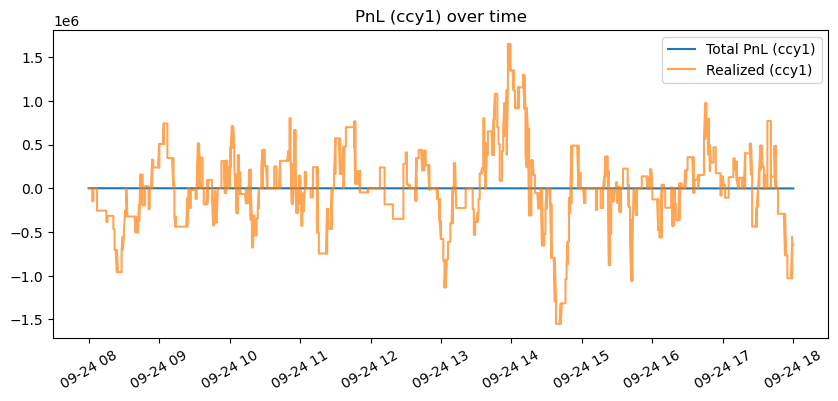

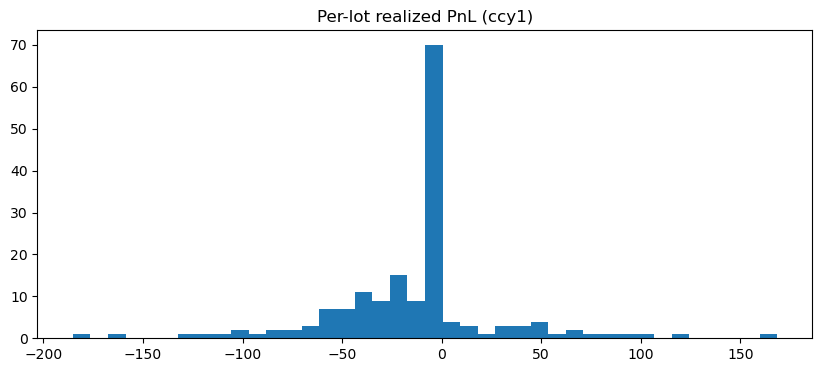

In [50]:
# Cell 8: plots
df_hist['ts'] = pd.to_datetime(df_hist['ts'])
df_hist = df_hist.sort_values('ts').reset_index(drop=True)

plt.figure()
plt.plot(df_hist['ts'], df_hist['total_pnl_ccy1'], label='Total PnL (ccy1)')
plt.plot(df_hist['ts'], df_hist['realized_pnl_ccy1'], label='Realized (ccy1)', alpha=0.7)
plt.legend(); plt.title("PnL (ccy1) over time"); plt.xticks(rotation=30); plt.show()

# per-lot realized PnL (ccy1)
if not df_lot_archive.empty:
    df_lot_archive['realized_ccy1'] = df_lot_archive['realized_ccy1'] if 'realized_ccy1' in df_lot_archive.columns else df_lot_archive['realized_ccy2'] / df_lot_archive['exit_px']
    plt.figure()
    plt.hist(df_lot_archive['realized_ccy1'], bins=40)
    plt.title("Per-lot realized PnL (ccy1)")
    plt.show()
else:
    print("No lot exits recorded in archive.")


# Parameter sweep including liquidity limits + visualization 

,tp_mult,sl_mult,hedge_cap_ccy2,final_pnl_ccy1,internalization_ratio,n_lot_closed
0,1.0,1.0,1000000.0,-2009.099433,0.279775,182
1,1.0,1.0,3000000.0,-2009.099433,0.279775,182
2,1.0,2.0,1000000.0,-1758.499222,0.361085,171
3,1.0,2.0,3000000.0,-1758.499222,0.361085,171
4,2.0,1.0,1000000.0,-2449.011848,0.295718,182
5,2.0,1.0,3000000.0,-2449.011848,0.295718,182
6,2.0,2.0,1000000.0,-2016.565223,0.387162,170
7,2.0,2.0,3000000.0,-2016.565223,0.387162,170
8,3.0,1.0,1000000.0,-2909.099971,0.317022,175
9,3.0,1.0,3000000.0,-2909.099971,0.317022,175


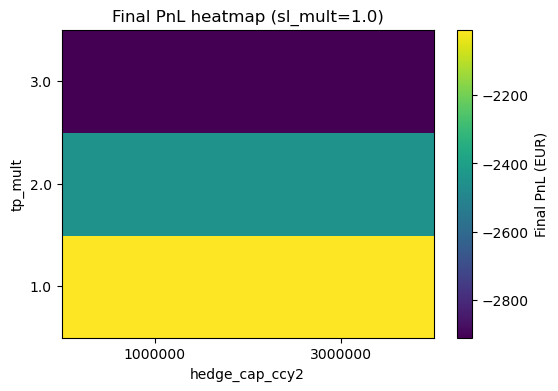

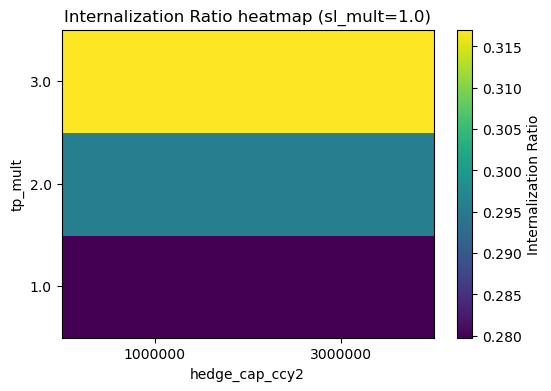

In [53]:
# Cell 9: Parameter sweep - sweep over (k_tp multiplier), (k_sl multiplier), and max_hedge_per_min_ccy2
def sweep_parameters(price_df, trade_df, tp_mult_list, sl_mult_list, hedge_cap_list):
    records = []
    for tp_mult in tp_mult_list:
        for sl_mult in sl_mult_list:
            for cap in hedge_cap_list:
                cfg = BacktestConfig(vol_multiplier_tp=tp_mult, vol_multiplier_sl=sl_mult, max_hedge_per_min_ccy2=cap)
                sim = run_full_simulation(price_df, trade_df, cfg, tp_sl_func=tp_sl_func)
                df_hist = sim.results_df()
                df_ledger = sim.ledger_df()
                df_lot_archive = sim.lot_archive_df()
                final_pnl = df_hist['total_pnl_ccy1'].iloc[-1]
                internal_total = df_ledger.loc[df_ledger['type']=="internalized", 'qty_ccy1'].abs().sum()
                external_total = df_ledger.loc[df_ledger['type']=="external", 'qty_ccy1'].abs().sum()
                internal_ratio = internal_total / (internal_total + external_total) if (internal_total + external_total)>0 else np.nan
                records.append({
                    "tp_mult": tp_mult, "sl_mult": sl_mult, "hedge_cap_ccy2": cap,
                    "final_pnl_ccy1": final_pnl,
                    "internalization_ratio": internal_ratio,
                    "n_lot_closed": len(df_lot_archive)
                })
    return pd.DataFrame(records)

# Example sweep (small grid)
tp_mults = [1.0, 2.0, 3.0]
sl_mults = [1.0, 2.0]
hedge_caps = [1e6, 3e6]

sweep_df = sweep_parameters(price_df, trade_df, tp_mults, sl_mults, hedge_caps)
display(sweep_df)

# heatmap final_pnl vs (tp_mult, hedge_cap) for a fixed sl_mult (pick the first sl_mult)
sl_fixed = sl_mults[0]
pivot = sweep_df[sweep_df['sl_mult']==sl_fixed].pivot(index='tp_mult', columns='hedge_cap_ccy2', values='final_pnl_ccy1')
plt.figure(figsize=(6,4))
plt.imshow(pivot, origin='lower', aspect='auto')
plt.colorbar(label=f"Final PnL ({cfg.ccy1})")
plt.xticks(range(len(pivot.columns)), [int(x) for x in pivot.columns])
plt.yticks(range(len(pivot.index)), [float(x) for x in pivot.index])
plt.xlabel("hedge_cap_ccy2")
plt.ylabel("tp_mult")
plt.title(f"Final PnL heatmap (sl_mult={sl_fixed})")
plt.show()

# internalization heatmap
pivot2 = sweep_df[sweep_df['sl_mult']==sl_fixed].pivot(index='tp_mult', columns='hedge_cap_ccy2', values='internalization_ratio')
plt.figure(figsize=(6,4))
plt.imshow(pivot2, origin='lower', aspect='auto')
plt.colorbar(label="Internalization Ratio")
plt.xticks(range(len(pivot2.columns)), [int(x) for x in pivot2.columns])
plt.yticks(range(len(pivot2.index)), [float(x) for x in pivot2.index])
plt.xlabel("hedge_cap_ccy2")
plt.ylabel("tp_mult")
plt.title(f"Internalization Ratio heatmap (sl_mult={sl_fixed})")
plt.show()
